<center><b><font size="5">Closure tests without and with DR</font></b></center>

Let's study the possibility of extraction of CFFs from simulated data, and in particular how to get reliable error bands, using the so-called closure tests, using the NeuralModel with dispersion relation.

This notebook only shows that things work in principle, i.e. that Gepard and its DR extension function properly. To get closure tests with DR will require nontrivial extra work!

# Initializations

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import gepard as g
import gepard.plots as gplots
from gepard.fits import GLO15new, AUTIpts, ALUIpts
print('Gepard version = {}'.format(g.__version__))

Gepard version = 0.9.10


In [3]:
# This just gets my current git revision hash, in case version number above is not reliable.
# You should comment this cell out if your Gepard installation is not git cloned from github repository.
import os
import subprocess
branch = subprocess.check_output(['git', '-C', os.path.dirname(g.__file__),
                                  'branch', '--show-current']).decode('ascii').strip()
revhash = subprocess.check_output(['git', '-C', os.path.dirname(g.__file__),
                                   'rev-parse', 'HEAD']).decode('ascii').strip()
print('Current git branch is "{}" and revision hash is {}'.format(branch, revhash))

Current git branch is "dev_Mel" and revision hash is dd5e2aceae4d24c8f1365249b8d77a273a66969e


In [4]:
import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.integrate import quad

`torch` branch works only with Neural models, but we want to generate simulated
data with KM and GK models. So we take `master` Gepard branch, rename
`gepard -> gmaster` in 3 places in `setup.py` and `setup.cfg`, and by
`pip install -e .` we install 
official Gepard package under the alternative name `gmaster`.

In [5]:
import gmaster as gm  # need KM15 for simulated data
from gmaster.fits import th_KM15, par_KM15

In [6]:
xi = 0.2  # needed by NNTestDR subtraction() but likely not actually used

## NN classes

In [7]:
class NNTest(g.model.NeuralModel, g.eff.KellyEFF, g.dvcs.BMK):    

    def build_net(self):
            '''Overriding the default architecture and optimizer'''
            nn_model = torch.nn.Sequential(
                    torch.nn.Linear(2, 23),
                    torch.nn.ReLU(),
                    torch.nn.Linear(23, 37),
                    torch.nn.ReLU(),
                    torch.nn.Linear(37, 19),
                    torch.nn.ReLU(),
                    torch.nn.Linear(19, len(self.output_layer))
                )
            optimizer = torch.optim.Rprop(nn_model.parameters(), lr=0.01 ) #lr=0.05 #2e-3
            return nn_model, optimizer

In [8]:
import torch.nn as nn
class CustomNetwork(nn.Module):
    def __init__(self):
        super(CustomNetwork, self).__init__()

        # Define the layers for the network
        self.n1 = nn.Linear(2, 20)  # 2 input features, 12 hidden units
        self.n2 = nn.Linear(20, 25)  # 12 hidden units, 17 hidden units
        self.n3 = nn.Linear(25, 1)  # 7 hidden units, 1 output features
        
        self.n1p = nn.Linear(1, 20)  # 2 input features, 12 hidden units
        self.n2p = nn.Linear(20, 25)  # 12 hidden units, 17 hidden units
        self.n3p = nn.Linear(25, 1)  # 17 hidden units, 1 output features

    def forward(self, x):
        
       
        x0 = x
        
        # Build Im network
        x = torch.relu(self.n1(x0))
        x = torch.relu(self.n2(x))
        output1 = self.n3(x)
        
        # Build D network
        # build the input tensor
        x0_1 = torch.cat((x0[:,1].unsqueeze(1),), dim=0)
       
        x2 = torch.relu(self.n1p(x0_1))
        x2 = torch.relu(self.n2p(x2))
        output2 = self.n3p(x2)
        
        #concatenate outputs
        output = torch.cat((output1, output2), dim=1)
       
        return output 

In [9]:
class NNTest_DR(g.model.NeuralModel_DR, g.eff.KellyEFF, g.dvcs.BM10tw2, g.cff.DispersionCFF):
    
    def build_net(self):
        '''Overriding the default architecture and optimizer'''
        nn_model = CustomNetwork()
        optimizer = torch.optim.Rprop(nn_model.parameters(),
                lr=0.01)
        return nn_model, optimizer
    
    def subtraction(self, pt): #This should use the NN, the real part will be calculated by the CFF_Dispersion methods
        """Subtraction constant."""
        #refer to the location of D in output layer (defined in the next cell)
        return self.cffs(1, pt, xi)
    
    def ImH(self, pt, xi=0) -> float:
        """Return Im(CFF H) for kinematic point."""
        #refer to the location of Im H in output layer (defined in the next cell)
        return self.cffs(0, pt, xi)
    
    def ImE(self, pt, xi=0):
        """Return Im(CFF E) for kinematic point."""
        return self.zero(pt)
    
    def ImHt(self, pt, xi=0):
        """Return Im(CFF Ht) for kinematic point."""
        return self.zero(pt)
    
    def ImEt(self, pt, xi=0):
        """Return Im(CFF Et) for kinematic point."""
        return self.zero(pt)

# Model for generation of artificial data

We start from KM15 model, but we kill all CFFs, save `ImH`, `ReH` and part of `ReE` coming from DR.

In [10]:
class KM15(gm.eff.KellyEFF, gm.gpd.PWNormGPD, gm.cff.HybridFreePoleCFF, gm.dvcs.BM10tw2):

    pass

th_KM15_H = KM15()
th_KM15_H.parameters.update(par_KM15)
th_KM15_H.parameters.update({'trv':0, 'rpi':0})
th_KM15_H.name = 'KM15_H'

In [11]:
th_KM15_H.print_CFFs(g.dset[101][0])

 ImH =  6.74
 ReH = -2.97
 ImE =  0.00
 ReE =  2.39
ImHt =  0.00
ReHt =  0.00
ImEt =  0.00
ReEt =  0.00



In [12]:
th_KM15_H.subtraction(g.DataPoint(xB=0.1, t=0., Q2=4.))

2.7678681812890016

# Simulation - XLU+XUU - ImH and D - xB and t-dep - noise

## Generation of simulated data

In [13]:
mocksetXLU = []
for xB in np.linspace(0.18, 0.25, 4):
    for tm in np.linspace(0.1, 0.5, 4):
        pt = g.DataPoint(xB=xB, t=-tm, Q2=torch.tensor(1.7), FTn=-1,
                      process='ep2epgamma', exptype='fixed target', frame='Trento',
                      in1energy=6., in1charge=-1, in1polarization=+1,
                      observable='XLU')
        ptgm = g.DataPoint(xB=xB, t=-tm, Q2=1.7, FTn=-1,
                      process='ep2epgamma', exptype='fixed target', frame='Trento',
                      in1energy=6., in1charge=-1, in1polarization=+1,
                      observable='XLU')
        pt.id = 4001
        pt.year = 2025
        pt.collaboration = 'mock'
        pt.reference = 'mock'
        pt.val = th_KM15_H.predict(ptgm)
        pt.err = 0.1 * np.abs(pt.val) + 0.0002
        pt.val = pt.val + np.random.normal(0, pt.err, 1)[0]  # noise
        mocksetXLU.append(pt)
mocksetXLU = g.DataSet(mocksetXLU)

In [14]:
mocksetXUU = []
for xB in np.linspace(0.18, 0.25, 4):
    for tm in np.linspace(0.1, 0.5, 4):
        pt = g.DataPoint(xB=xB, t=-tm, Q2=torch.tensor(1.7), FTn=0,
                      process='ep2epgamma', exptype='fixed target', frame='Trento',
                      in1energy=6., in1charge=-1, in1polarization=+1,
                      observable='XUU')
        ptgm = g.DataPoint(xB=xB, t=-tm, Q2=1.7, FTn=0,
                      process='ep2epgamma', exptype='fixed target', frame='Trento',
                      in1energy=6., in1charge=-1, in1polarization=+1,
                      observable='XUU')
        pt.id = 4002
        pt.year = 2025
        pt.collaboration = 'mock'
        pt.reference = 'mock'
        pt.val = th_KM15_H.predict(ptgm)
        pt.err = 0.1 * np.abs(pt.val) + 0.0002
        pt.val = pt.val + np.random.normal(0, pt.err, 1)[0]  # noise
        mocksetXUU.append(pt)
mocksetXUU = g.DataSet(mocksetXUU)

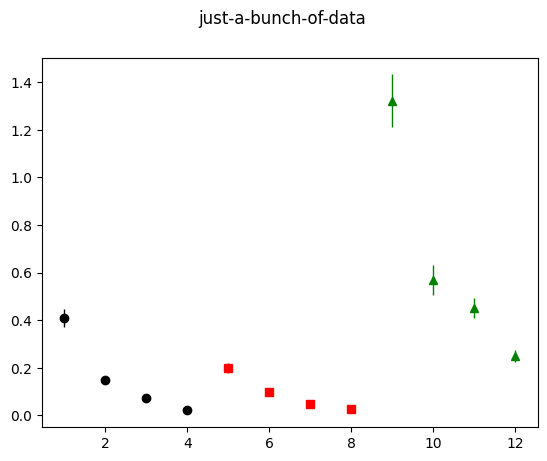

In [15]:
fig = gplots.jbod(points=[mocksetXLU[:4], mocksetXLU[4:8], mocksetXUU[4:8]])

In [16]:
g.describe_data(mocksetXLU+mocksetXUU)

npt x obs     collab  FTn    id  ref.        
----------------------------------------------
16 x XLU     mock    -1     4001 mock        
16 x XUU     mock    0      4002 mock        
----------------------------------------------
TOTAL = 32


## Fit by DR-unconstrained NNets

In [17]:
th = NNTest(output_layer=['ImH', 'ReH'])
th.name = 'CFF H (No DR)'
print(th.useDR)

None


In [18]:
f = g.fitter.NeuralFitter([mocksetXLU, mocksetXUU], th, nnets=2, nbatch=6, batchlen=3, regularization='L2', lx_lambda=0.01)
f.fit()


Epoch   3: train error = 42.6661 test error = 34.8570 -
Epoch   6: train error = 10.3838 test error = 50.0610 +
Epoch   9: train error = 4.5620 test error = 12.4233 -
Epoch  12: train error = 4.1918 test error = 10.2655 -
Epoch  15: train error = 2.4814 test error = 11.5736 +
Epoch  18: train error = 2.1093 test error = 11.6283 +Net 0 --> test_err = 10.265537481282005

Epoch   3: train error = 34.9774 test error = 20.4376 -
Epoch   6: train error = 18.8251 test error = 7.8704 -
Epoch   9: train error = 5.6302 test error = 3.2186 -
Epoch  12: train error = 3.0460 test error = 2.3566 -
Epoch  15: train error = 2.0936 test error = 2.9760 +
Epoch  18: train error = 1.9473 test error = 3.6557 +Net 1 --> test_err = 2.3566398514868534


In [19]:
print(th.chisq(mocksetXLU))
print(th.chisq(mocksetXUU))

(np.float64(52.4126518718885), 16, np.float64(9.39466845306658e-06))
(np.float64(24.275289374520494), 16, np.float64(0.08366192279504248))


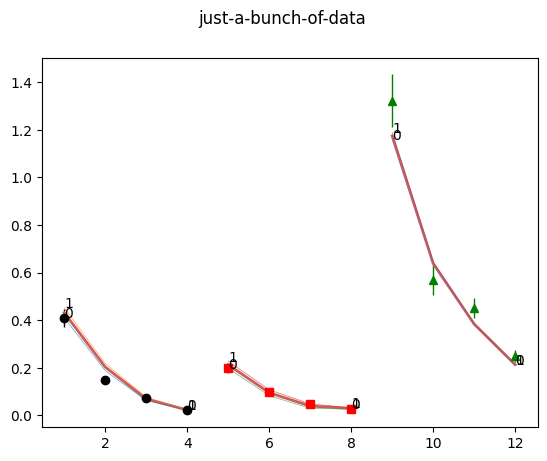

In [20]:
fig = gplots.jbod(points=[mocksetXLU[:4], mocksetXLU[4:8], mocksetXUU[4:8]],
                  lines=[th], mesh=th )

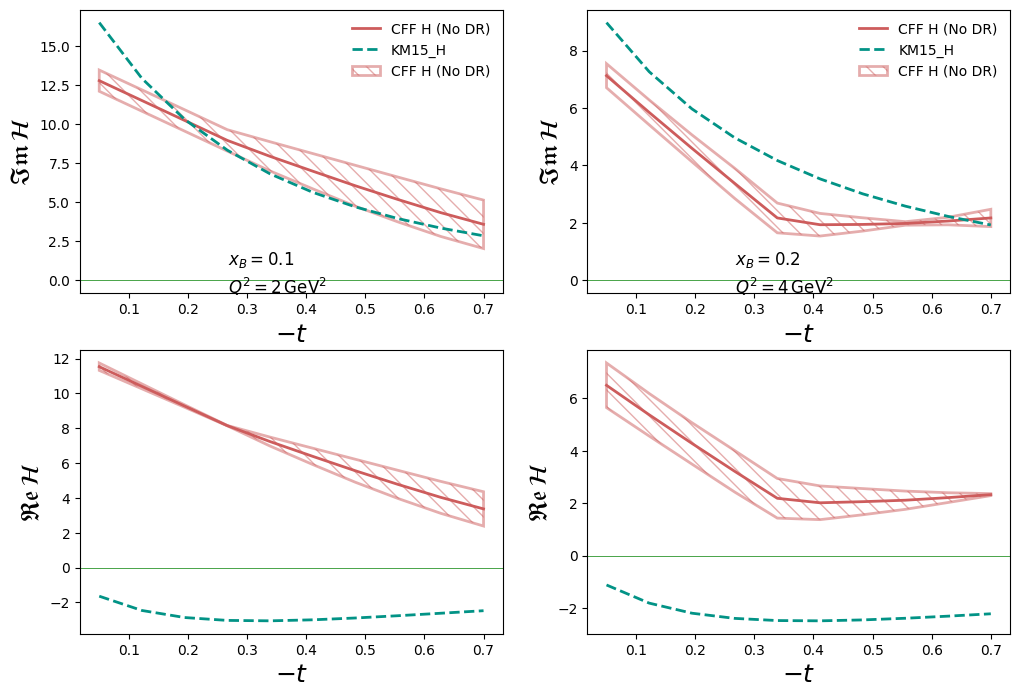

In [21]:
fig = gplots.CFFt(cffs=['ImH', 'ReH'], lines=[th, th_KM15_H], bands=[th])

## Fit by DR-constrained NNets

In [22]:
th = NNTest_DR(output_layer=['ImH', 'D'])
th.name = 'fit-ImH-D'

In [23]:
f = g.fitter.NeuralFitter([mocksetXLU, mocksetXUU], th, nnets=2, nbatch=6, batchlen=3, regularization='L2', lx_lambda=0.01)
f.fit()


Epoch   3: train error = 52.6458 test error = 35.4159 -
Epoch   6: train error = 37.9410 test error = 17.3608 -
Epoch   9: train error = 15.7643 test error = 25.3374 +
Epoch  12: train error = 5.9671 test error = 9.7067 -
Epoch  15: train error = 2.6191 test error = 6.4592 -
Epoch  18: train error = 1.7539 test error = 5.8442 -Net 0 --> test_err = 5.844244569724016

Epoch   3: train error = 43.4572 test error = 38.1255 -
Epoch   6: train error = 26.4021 test error = 14.0152 -
Epoch   9: train error = 5.5037 test error = 16.8784 +
Epoch  12: train error = 3.9135 test error = 2.1728 -
Epoch  15: train error = 2.7933 test error = 1.4377 -
Epoch  18: train error = 2.0435 test error = 1.2655 -Net 1 --> test_err = 1.2655172709640226


In [24]:
print(th.chisq(mocksetXLU))
print(th.chisq(mocksetXUU))

(np.float64(24.84042856990189), 16, np.float64(0.07268837645832682))
(np.float64(15.561480727146652), 16, np.float64(0.4839620330283052))


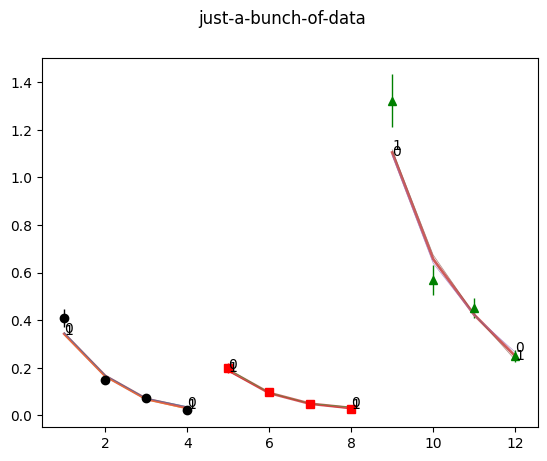

In [25]:
fig = gplots.jbod(points=[mocksetXLU[:4], mocksetXLU[4:8], mocksetXUU[4:8]],
                  lines=[th], mesh=th )

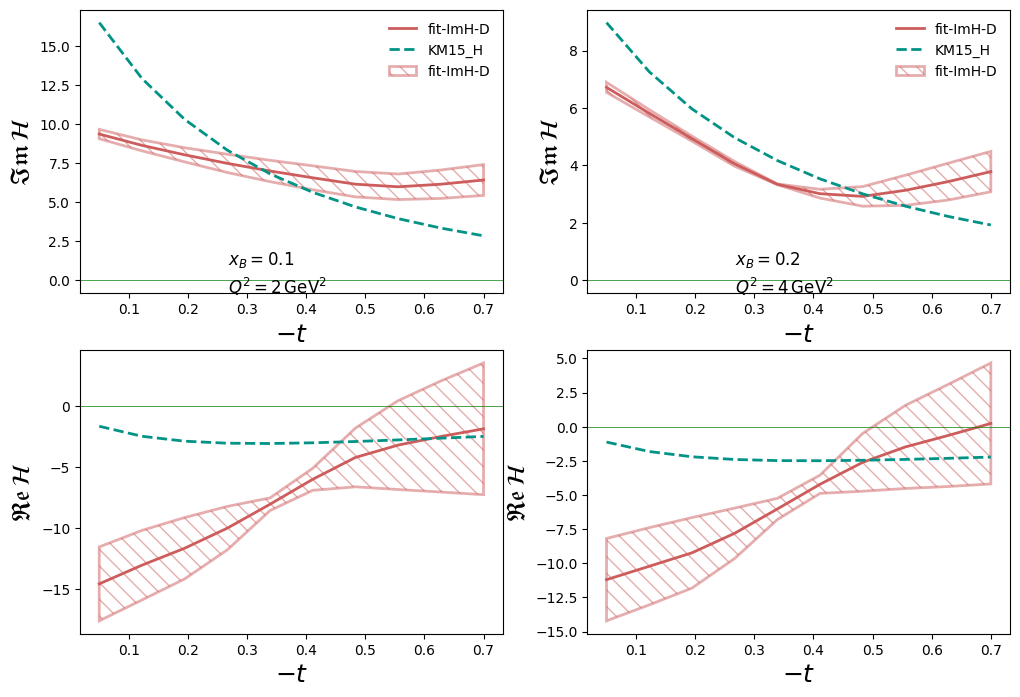

In [26]:
fig = gplots.CFFt(cffs=['ImH', 'ReH'], lines=[th, th_KM15_H], bands=[th])

In [27]:
th.subtraction(mocksetXLU[0]), th_KM15_H.subtraction(mocksetXLU[0])

(tensor([1.9983], grad_fn=<MulBackward0>), np.float64(2.4221888866783625))

So, to get successful closure test including DR requires extra work!